In [1]:
import pandas as pd
import numpy as np

# Import data set and then partition

exclude valence from spotify features to prevent leakeage

In [2]:
df = pd.read_csv("output.csv", index_col=0).drop_duplicates(['spotify_id'])
y = df[["valence_tags", "dominance_tags", "arousal_tags"]]
X = df.select_dtypes(include='number').drop(columns=["valence_tags", "dominance_tags", "arousal_tags", "time_signature", "valence"])

In [3]:
FEATURE_COLS = X.columns
X.isna().sum()

popularity                0
duration_ms               0
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
tempo                     0
number_of_emotion_tags    0
dtype: int64

In [4]:
y.isna().sum()

valence_tags      0
dominance_tags    0
arousal_tags      0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Modelling


## clustering

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize structures to keep track of results for each value of k
kmeans_labels = {}
kmean_scores = {}

for k in range(2, 15):
  print("Clustering with", str(k), "clusters")

  # Fit the clusters
  kmeans = KMeans(n_clusters=k, max_iter=300, random_state=67)
  labels = kmeans.fit_predict(y)

  # Save the results
  kmeans_labels[k] = labels
  kmean_scores[k] = silhouette_score(y, labels)

Clustering with 2 clusters
Clustering with 3 clusters
Clustering with 4 clusters
Clustering with 5 clusters
Clustering with 6 clusters
Clustering with 7 clusters
Clustering with 8 clusters
Clustering with 9 clusters
Clustering with 10 clusters
Clustering with 11 clusters
Clustering with 12 clusters
Clustering with 13 clusters
Clustering with 14 clusters


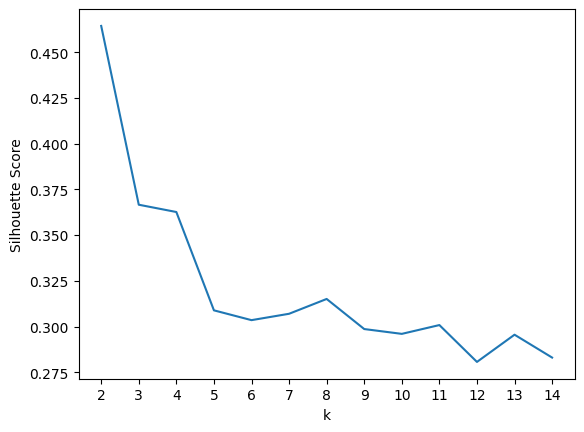

In [7]:

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Plot the silhouette scores as a function of k
plt.plot(range(2,15), kmean_scores.values())
plt.xticks(range(2,15))
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [8]:
y.loc[:, "8_clusters"] = kmeans_labels[8]
y.loc[:, "4_clusters"] = kmeans_labels[4]

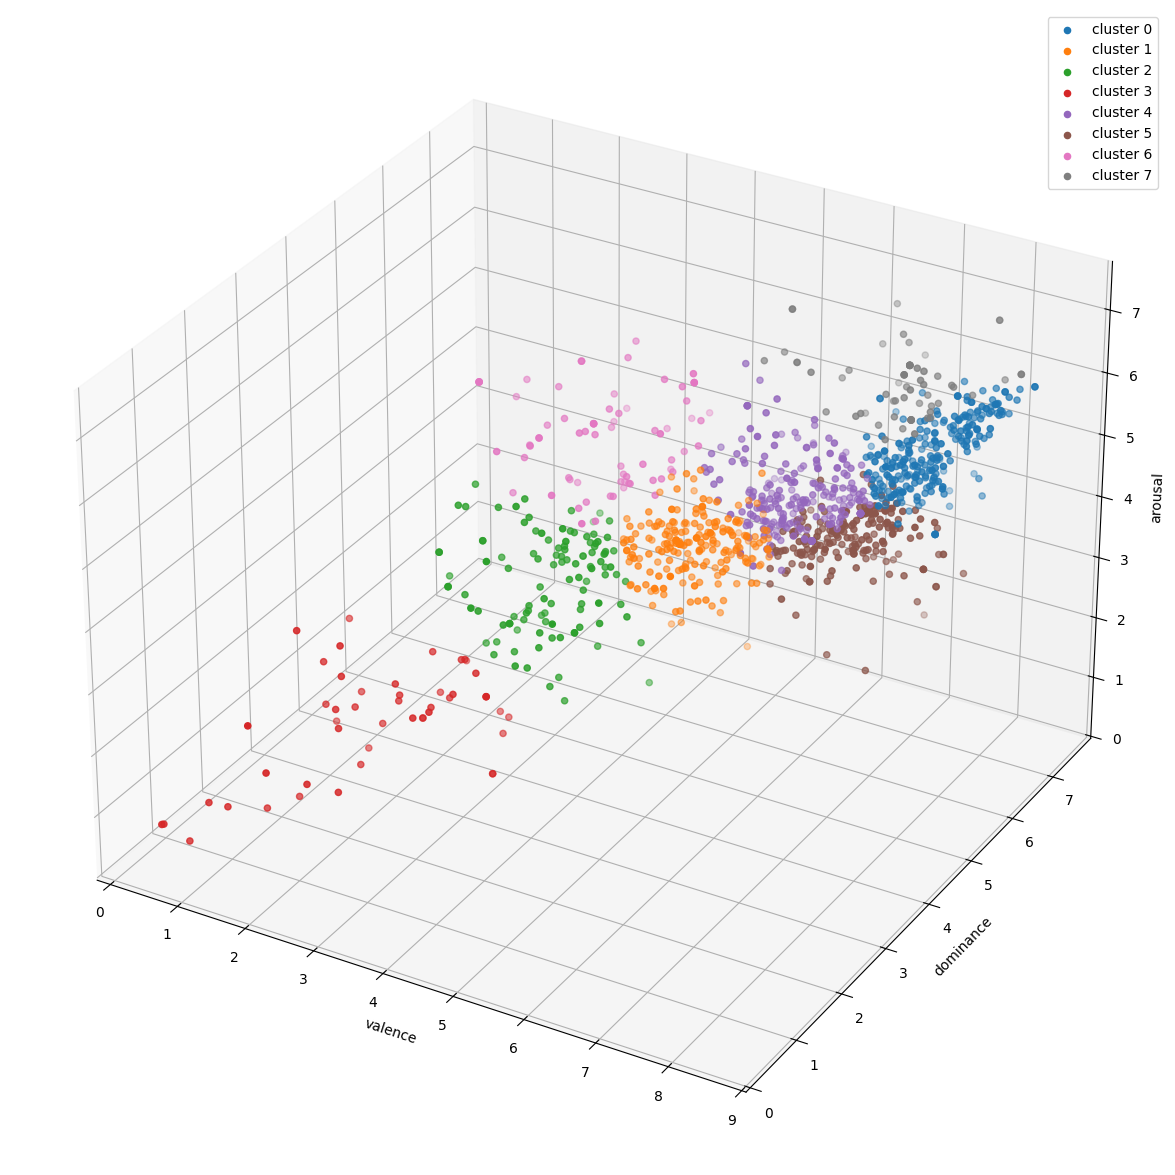

In [9]:
# 3d scatterplot using matplotlib

fig = plt.figure(figsize = (15,15))
ax = fig.add_subplot(111, projection='3d')
for group in range(8):
    drawing_data = y[kmeans_labels[8] == group].to_numpy().T
    ax.scatter(drawing_data[0], drawing_data[1], drawing_data[2], label=f"cluster {group}")

ax.set_xlabel('valence')
ax.set_ylabel('dominance')
ax.set_zlabel('arousal')
ax.legend()
plt.show()

In [10]:
import plotly.express as px

fig = px.scatter_3d(y, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='8_clusters')
fig.show()

In [95]:
import plotly.express as px

fig = px.scatter_3d(y, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='4_clusters')
fig.show()

I will do classification on 4 clusters as they seem more understandable. I use the graph and cluster songs to give word labels to clusters.

In [13]:
df[kmeans_labels[4] == 0].sort_values('popularity', ascending=False).head()
# Energetic

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
606,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,0,...,I Wanna Be Yours,Arctic Monkeys,['sexy'],5,7.052444,5.788000,5.925778,a1ff202f-f271-4646-9aac-ba7c98e3a50c,5XeFesFbtLpXzIVDNQP22n,indie rock
1122,5O2P9iiztwhomNh8xkR9lJ,One Direction,FOUR (Deluxe),Night Changes,88,226600,False,0.672,0.520,8,...,Night Changes,One Direction,['romantic'],3,7.883478,5.438261,6.170435,f4fb45d5-a3c7-4da8-9bcc-8ae65d6b64a5,5O2P9iiztwhomNh8xkR9lJ,pop
607,5FVd6KXrgO9B3JPmC8OPst,Arctic Monkeys,AM,Do I Wanna Know?,88,272394,False,0.548,0.532,5,...,Do I Wanna Know?,Arctic Monkeys,['sexy'],3,7.523529,6.542353,6.088235,f1e57531-e0df-4b3e-938f-1ae30c5b1a11,5FVd6KXrgO9B3JPmC8OPst,indie rock
1423,0pqnGHJpmpxLKifKRmU6WP,Imagine Dragons,Evolve,Believer,88,204346,False,0.776,0.780,10,...,Believer,Imagine Dragons,['epic'],1,7.190000,4.800000,5.320000,NaN,0pqnGHJpmpxLKifKRmU6WP,rock
787,4woTEX1wYOTGDqNXuavlRC,Eminem;Dina Rae,The Eminem Show,Superman,86,350320,True,0.802,0.755,4,...,Superman,Eminem,['sexy'],16,6.594242,5.520606,5.668788,c966edc2-9e89-426f-84fe-cea42e6f672d,4woTEX1wYOTGDqNXuavlRC,rap


In [14]:
df[kmeans_labels[4] == 1].sort_values('popularity', ascending=False).head()
# Serenity 

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
1124,09mEdoA6zrmBPgTEN5qXmN,The Weeknd,"My Dear Melancholy,",Call Out My Name,89,228373,False,0.461,0.593,1,...,Call Out My Name,The Weeknd,"['sexy', 'sad']",3,5.840000,5.216667,5.253333,NaN,09mEdoA6zrmBPgTEN5qXmN,soul
1129,7fBv7CLKzipRk6EC6TWHOB,The Weeknd,Beauty Behind The Madness,The Hills,88,242253,True,0.585,0.564,0,...,The Hills,The Weeknd,['dark'],3,5.798966,4.507672,5.066466,NaN,7fBv7CLKzipRk6EC6TWHOB,r&b
219,62ke5zFUJN6RvtXZgVH0F8,Paloma Faith,A Perfect Contradiction (Outsiders' Expanded E...,Only Love Can Hurt Like This,87,232893,False,0.566,0.885,8,...,Only Love Can Hurt Like This,Paloma Faith,"['dramatic', 'euphoric']",7,6.287895,5.222105,5.092632,b335df76-5461-4362-b6a6-a700db16a052,62ke5zFUJN6RvtXZgVH0F8,british
1572,3xKsf9qdS1CyvXSMEid6g8,Frank Ocean,Blonde,Pink + White,85,184516,False,0.545,0.545,9,...,Pink + White,Frank Ocean,"['sad', 'smooth', 'optimistic']",4,5.126000,3.612000,5.384000,NaN,3xKsf9qdS1CyvXSMEid6g8,soul
500,2Fxmhks0bxGSBdJ92vM42m,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",bad guy,84,194087,False,0.701,0.425,7,...,bad guy,Billie Eilish,"['quirky', 'quiet']",2,6.450000,3.150000,5.810000,NaN,2Fxmhks0bxGSBdJ92vM42m,pop


In [15]:
df[kmeans_labels[4] == 2].sort_values('popularity', ascending=False).head()
# Anxious 

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
1123,0u2P5u6lvoDfwTYjAADbn4,Billie Eilish;Khalid,lovely (with Khalid),lovely (with Khalid),89,200185,False,0.351,0.296,4,...,lovely (with Khalid),Billie Eilish,['sad'],2,3.630000,3.370000,4.695000,NaN,0u2P5u6lvoDfwTYjAADbn4,pop
501,3ZCTVFBt2Brf31RLEnCkWJ,Billie Eilish,everything i wanted,everything i wanted,86,245425,False,0.704,0.225,6,...,Everything I Wanted,Billie Eilish,['sad'],3,4.993333,4.263333,5.406667,NaN,3ZCTVFBt2Brf31RLEnCkWJ,pop
784,4xkOaSrkexMciUUogZKVTS,Eminem;Nate Dogg,The Eminem Show,Till I Collapse,86,297786,True,0.548,0.847,1,...,'Till I Collapse,Eminem,['aggressive'],6,4.550000,5.273125,5.690625,cab93def-26c5-4fb0-bedd-26ec4c1619e1,4xkOaSrkexMciUUogZKVTS,rap
785,3UmaczJpikHgJFyBTAJVoz,Eminem;Dido,The Marshall Mathers LP,Stan,85,404106,True,0.780,0.768,6,...,Stan,Eminem,['sad'],15,3.614706,3.644902,4.250784,60d2246d-2761-4e1f-b30b-2784f00565b1,3UmaczJpikHgJFyBTAJVoz,rap
783,0VgkVdmE4gld66l8iyGjgx,Future,FUTURE,Mask Off,83,204600,True,0.833,0.434,2,...,Mask Off,Future,"['dark', 'atmospheric']",2,5.400000,4.090000,4.860000,NaN,0VgkVdmE4gld66l8iyGjgx,hip-hop


In [16]:
df[kmeans_labels[4] == 3].sort_values('popularity', ascending=False).head()
# Defeated

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
536,0JP9xo3adEtGSdUEISiszL,XXXTENTACION,?,Moonlight,83,135090,True,0.921,0.537,9,...,Moonlight,xxxtentacion,['sad'],1,2.10,3.490,3.840,NaN,0JP9xo3adEtGSdUEISiszL,hip-hop
535,3ee8Jmje8o58CHK66QrVC2,XXXTENTACION,?,SAD!,83,166605,True,0.740,0.613,8,...,SAD!,xxxtentacion,['sad'],1,2.10,3.490,3.840,NaN,3ee8Jmje8o58CHK66QrVC2,hip-hop
788,7ycWLEP1GsNjVvcjawXz3z,A$AP Rocky;Skepta,TESTING,Praise The Lord (Da Shine) (feat. Skepta),82,205040,True,0.854,0.569,5,...,L$D,A$AP Rocky,['trippy'],2,2.58,1.625,2.775,NaN,7ycWLEP1GsNjVvcjawXz3z,hip-hop
390,7vGuf3Y35N4wmASOKLUVVU,Marshmello;Khalid,Silence,Silence,81,180822,False,0.520,0.761,4,...,Silence,Mar,['austere'],2,2.86,2.045,2.555,5b07dc43-0d87-4334-8213-6d7fedfe1060,7vGuf3Y35N4wmASOKLUVVU,ambient
534,7AFASza1mXqntmGtbxXprO,XXXTENTACION,?,changes,80,121886,False,0.669,0.308,11,...,changes,xxxtentacion,['sad'],2,2.25,3.150,3.840,NaN,7AFASza1mXqntmGtbxXprO,emo


In [17]:
y['4_clusters'] = y['4_clusters'].replace({0: "Energetic", 1: "Serenity", 2: "Anxious", 3: "Defeated"}).astype(dtype="string")

In [18]:
y['4_clusters']

0         Anxious
1       Energetic
2        Serenity
4       Energetic
5        Serenity
          ...    
1711      Anxious
1713     Serenity
1714     Serenity
1715      Anxious
1716     Serenity
Name: 4_clusters, Length: 1202, dtype: string

We can see that it matches previous EDA discovery that there is a strong linear correlation between valence and dominance. Overall, the data seem to distribute around a 3D plane.

Above could be used with CV, we now prepare clustering categories with train and test data in which test data is not used in clustering to prevent test leakage.

In [19]:
kmeans = KMeans(n_clusters=4, max_iter=300, random_state=67)
labels_train = kmeans.fit_predict(y_train)
labels_test = kmeans.predict(y_test)
y_train.loc[:, "4_clusters"] = labels_train
y_test.loc[:, "4_clusters"] = labels_test

In [20]:
import plotly.express as px

fig = px.scatter_3d(y_train, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='4_clusters')
fig.show()

In [21]:
import plotly.express as px

fig = px.scatter_3d(y_test, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='4_clusters')
fig.show()

In [22]:
y_train['4_clusters'] = y_train['4_clusters'].replace({0: "Defeated", 1: "Energetic", 2: "Anxious", 3: "Serenity"}).astype(dtype="string")
y_test['4_clusters'] = y_test['4_clusters'].replace({0: "Defeated", 1: "Energetic", 2: "Anxious", 3: "Serenity"}).astype(dtype="string")


## Classification

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
CV = KFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # avoid test leakage

scaler_full = StandardScaler()
X = scaler_full.fit_transform(X)

training_set = [X_train, y_train, X_test, y_test]


In [24]:

def cv_classification_report(model, X, y, cv, label):
    '''
    Run stratified K-fold cross-validation for a classifier and report results.

    Parameters
    ----------
    model  : sklearn estimator
    X      : feature matrix
    y      : encoded target array (integer labels)
    cv     : StratifiedKFold instance
    label  : string name for display / dict key

    Returns
    -------
    results : dict with keys label, acc_mean, acc_std, f1_mean, f1_std
    '''
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    # Macro-F1 treats all classes equally regardless of support
    f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

    acc_mean, acc_std = acc_scores.mean(), acc_scores.std()
    f1_mean,  f1_std  = f1_scores.mean(),  f1_scores.std()
    
    
    labels = ['accuracy', 'f1_scores']
    colors = ['peachpuff', 'orange']

    fig, ax = plt.subplots()

    bplot = ax.boxplot([acc_scores, f1_scores],
                    patch_artist=True,  # fill with color
                    tick_labels=labels)  # will be used to label x-ticks

    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    plt.show()

    print(f"[{label}]")
    print(f"  CV Accuracy : {acc_mean:.4f} +/- {acc_std:.4f}")
    print(f"  CV F1-macro : {f1_mean:.4f} +/- {f1_std:.4f}")
    print()

    return {
        'label'   : label,
        'acc_mean': acc_mean,
        'acc_std' : acc_std,
        'f1_mean' : f1_mean,
        'f1_std'  : f1_std,
    }

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score
def confusion_matrix(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train[['4_clusters']])
    y_preds = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test['4_clusters'],
        cmap=plt.cm.Blues,
    )
    disp.ax_.set_title(f'confusion matrix for {name} classifier')
    print(f"training accuracy {accuracy_score(y_pred=model.predict(X_train), y_true=y_train['4_clusters'])}")
    print(f"training F1-macro {f1_score(y_pred=model.predict(X_train), y_true=y_train['4_clusters'], average="macro")}")
    print(f"Testing accuracy {accuracy_score(y_pred=y_preds, y_true=y_test['4_clusters'])}")
    print(f"Testing F1-macro {f1_score(y_pred=y_preds, y_true=y_test['4_clusters'], average="macro")}")

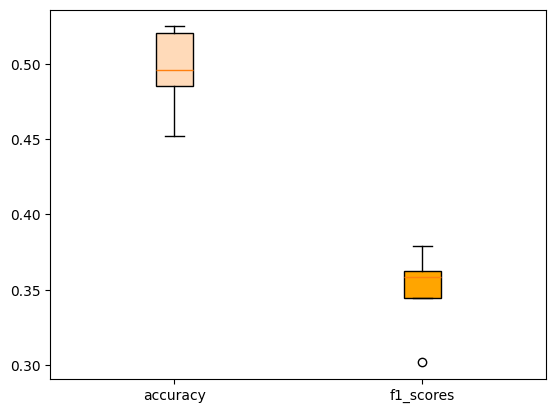

[Logistic Regression Baseline]
  CV Accuracy : 0.4959 +/- 0.0264
  CV F1-macro : 0.3491 +/- 0.0261

training accuracy 0.5234131113423517
training F1-macro 0.3876742018914249
Testing accuracy 0.46887966804979253
Testing F1-macro 0.33175852791824245


/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


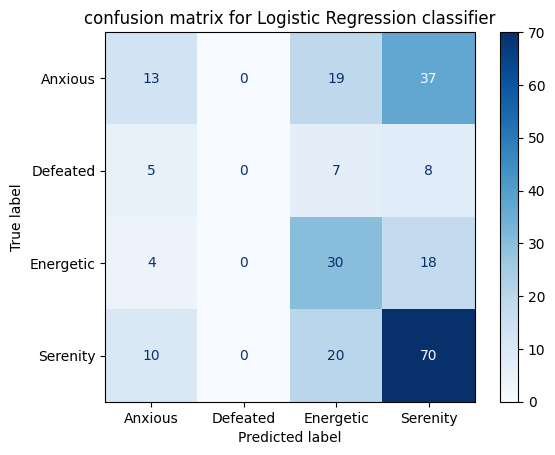

In [26]:
lr_baseline = LogisticRegression(
    max_iter=1500,
    solver='lbfgs',
    random_state=42
)

results_lr_baseline = cv_classification_report(
    lr_baseline, X, y['4_clusters'], CV, label='Logistic Regression Baseline'
)

confusion_matrix(lr_baseline, *training_set, "Logistic Regression")


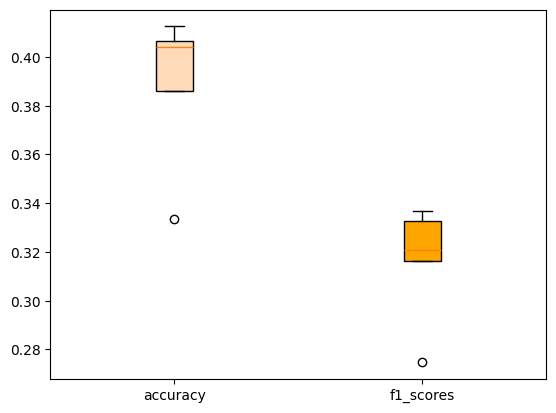

[Decision Tree]
  CV Accuracy : 0.3885 +/- 0.0290
  CV F1-macro : 0.3162 +/- 0.0221

training accuracy 1.0
training F1-macro 1.0
Testing accuracy 0.35269709543568467
Testing F1-macro 0.28329490557751424


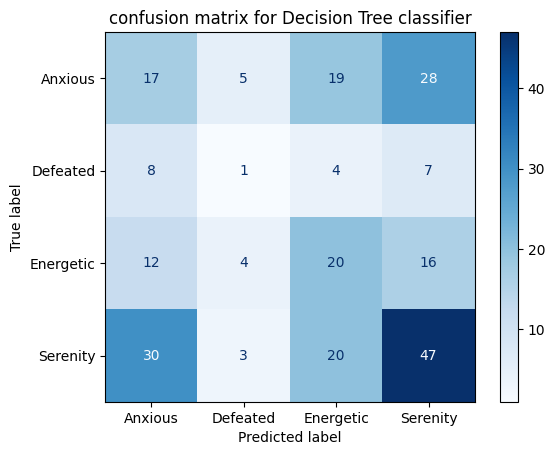

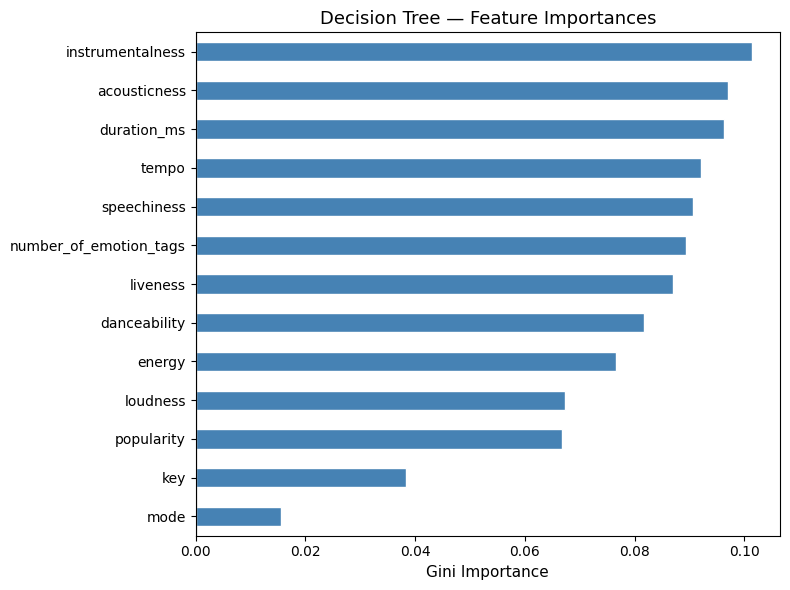

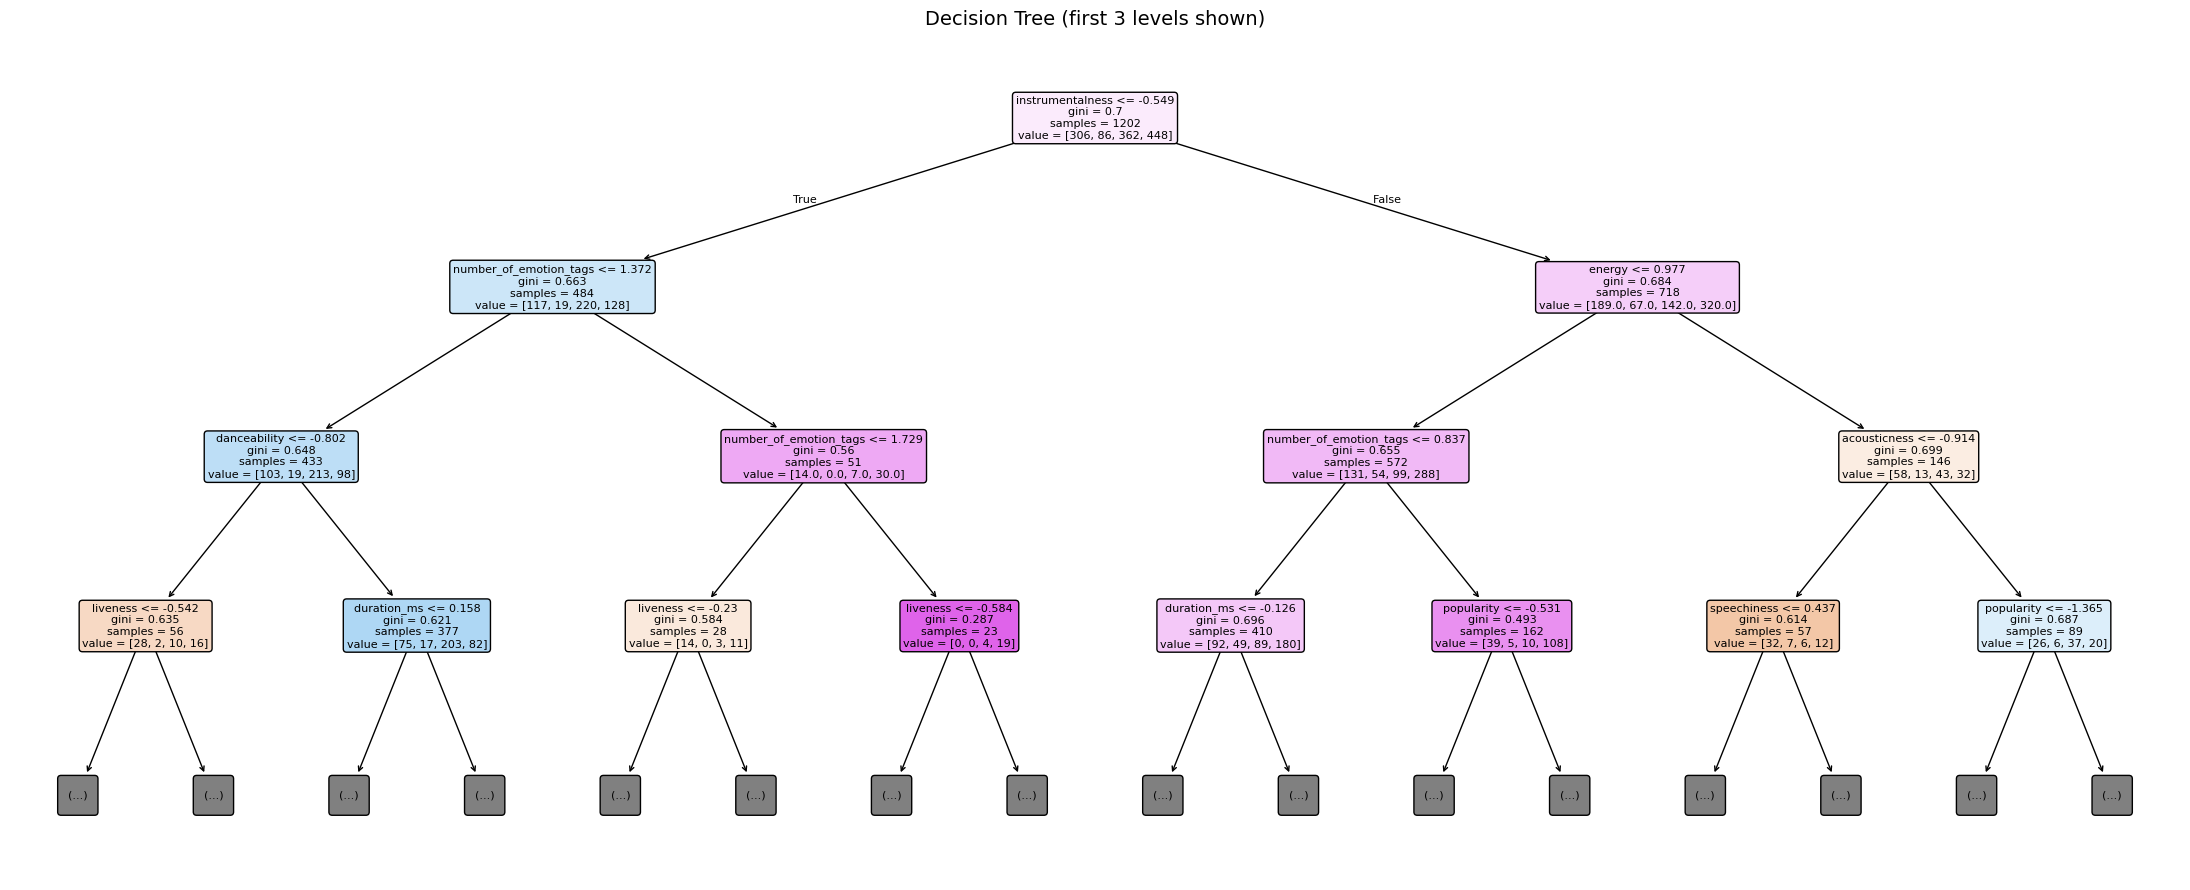

What the tree learned about arousal:
  Top 2 splitting features: ['instrumentalness', 'acousticness', 'duration_ms']
  The tree partitions songs primarily on these acoustic cues,
  suggesting they are most discriminative for arousal level.



In [110]:
# decision tree


dt = DecisionTreeClassifier(random_state=42)

results_dt = cv_classification_report(
    dt, X, y['4_clusters'], CV, label='Decision Tree'
)

confusion_matrix(dt, *training_set, "Decision Tree")

dt.fit(X, y['4_clusters'])

# ---- Feature importance bar chart ---
fi_dt = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi_dt.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Decision Tree — Feature Importances', fontsize=13)
ax.set_xlabel('Gini Importance', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('c4_dt_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Tree visualisation (limited to depth=3 for readability) ---
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    max_depth=3,
    feature_names=FEATURE_COLS,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (first 3 levels shown)', fontsize=14)
plt.tight_layout()
plt.savefig('c4_dt_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

top_dt = fi_dt.sort_values(ascending=False).head(3).index.tolist()
print("What the tree learned about arousal:")
print(f"  Top 2 splitting features: {top_dt}")
print("  The tree partitions songs primarily on these acoustic cues,")
print("  suggesting they are most discriminative for arousal level.\n")

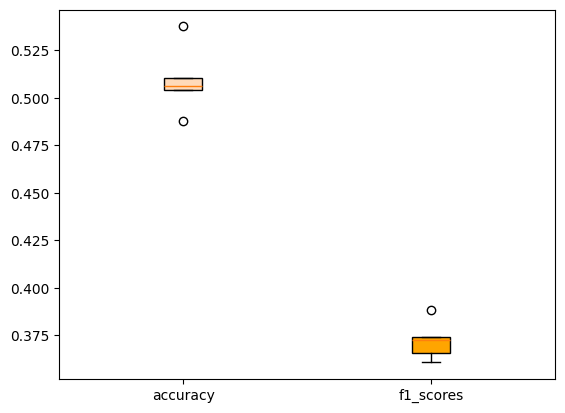

[Random Forest]
  CV Accuracy : 0.5092 +/- 0.0162
  CV F1-macro : 0.3723 +/- 0.0094



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


training accuracy 1.0
training F1-macro 1.0
Testing accuracy 0.47717842323651455
Testing F1-macro 0.3476096784016115


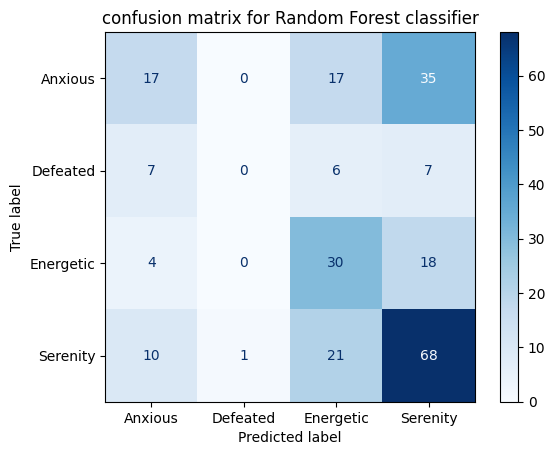

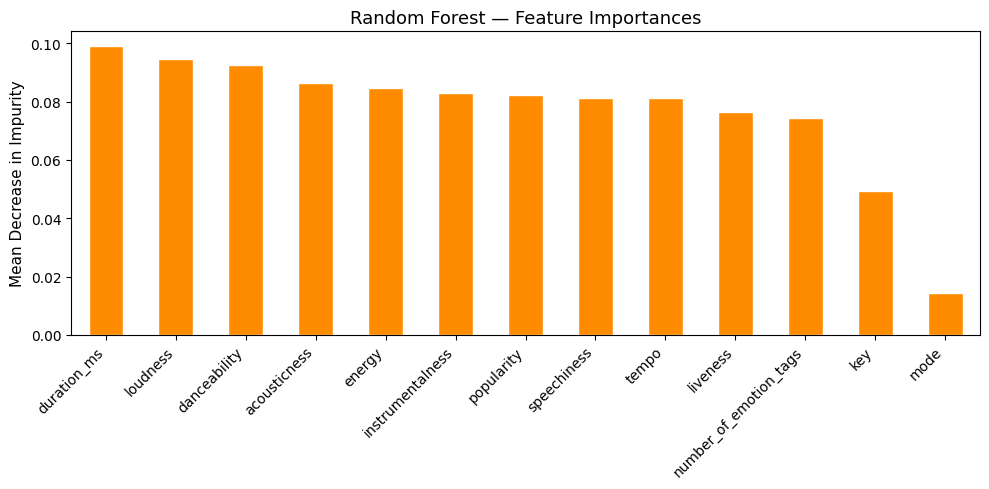

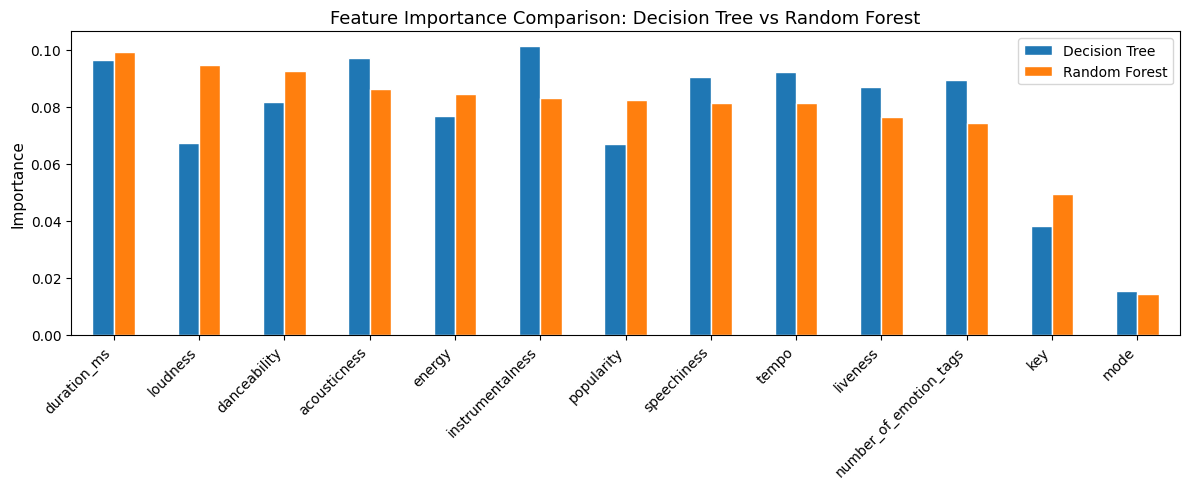

Bias-Variance note:
  A single decision tree has low bias but high variance — small data
  perturbations can drastically change which splits are chosen.
  Random Forest averages 100 de-correlated trees (bagging + feature
  subsampling), reducing variance while accepting a slight bias increase.
  This typically yields better generalisation (higher CV scores).



In [111]:
# RANDOM FOREST (ENSEMBLE)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

results_rf = cv_classification_report(
    rf, X, y['4_clusters'], CV, label='Random Forest'
)

confusion_matrix(rf, *training_set, "Random Forest")

rf.fit(X, y['4_clusters'])

fi_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi_rf.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_ylabel('Mean Decrease in Impurity', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('c5_rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Comparison with Decision Tree importances ---
compare_fi = pd.DataFrame({
    'Decision Tree': pd.Series(dt.feature_importances_,  index=FEATURE_COLS),
    'Random Forest': pd.Series(rf.feature_importances_, index=FEATURE_COLS),
}).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
compare_fi.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', fontsize=13)
ax.set_ylabel('Importance', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('c5_dt_vs_rf_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bias-Variance note:")
print("  A single decision tree has low bias but high variance — small data")
print("  perturbations can drastically change which splits are chosen.")
print("  Random Forest averages 100 de-correlated trees (bagging + feature")
print("  subsampling), reducing variance while accepting a slight bias increase.")
print("  This typically yields better generalisation (higher CV scores).\n")

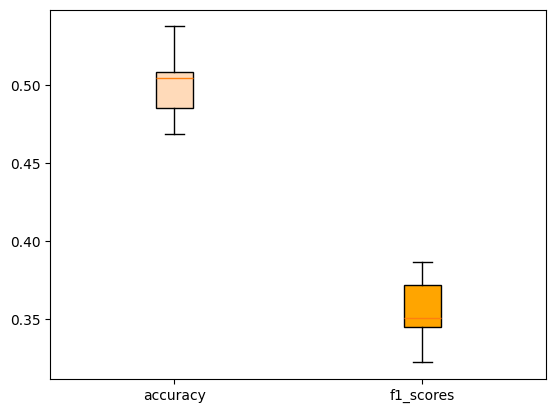

[MPL (0)]
  CV Accuracy : 0.5009 +/- 0.0231
  CV F1-macro : 0.3555 +/- 0.0221



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


training accuracy 0.5202913631633714
training F1-macro 0.38804414920659813
Testing accuracy 0.4730290456431535
Testing F1-macro 0.3369898164861913


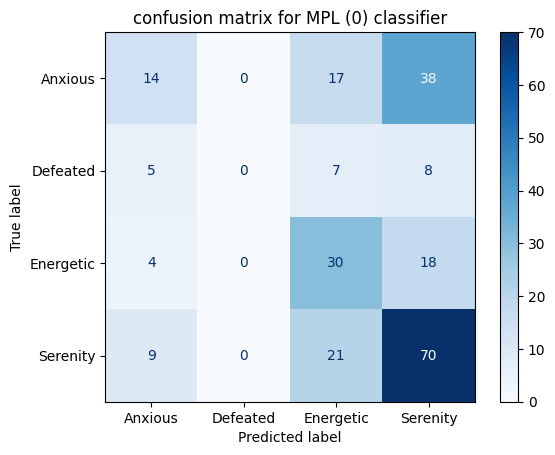

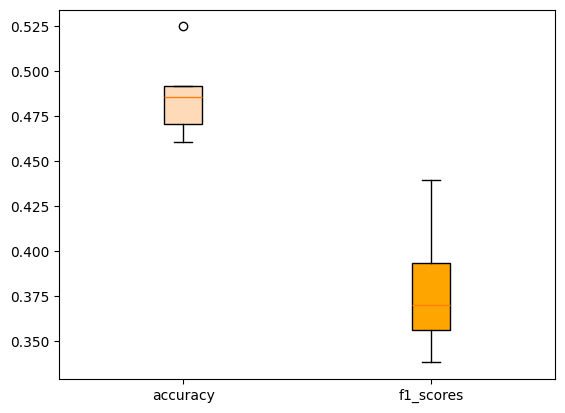

[MPL (16)]
  CV Accuracy : 0.4867 +/- 0.0220
  CV F1-macro : 0.3795 +/- 0.0351



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


training accuracy 0.6014568158168574
training F1-macro 0.5074773521416039
Testing accuracy 0.4190871369294606
Testing F1-macro 0.31958267099776533


/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13

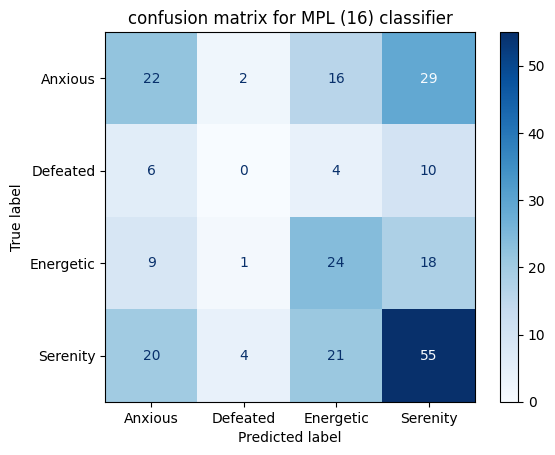

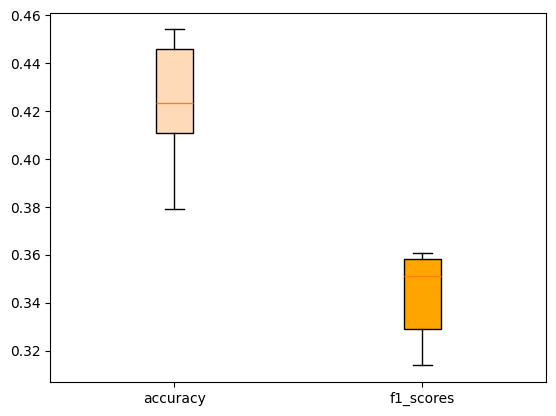

[MLP (32, 8)]
  CV Accuracy : 0.4226 +/- 0.0267
  CV F1-macro : 0.3426 +/- 0.0182



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


training accuracy 0.8116545265348595
training F1-macro 0.794905946256805
Testing accuracy 0.4190871369294606
Testing F1-macro 0.35858227448388935
Comparison with simpler models:
  LR Baseline accuracy : 0.4959
  Decision Tree accuracy: 0.3885
  Random Forest accuracy: 0.5092
  MLP (16,) accuracy   : 0.4867
  MLP (32,8) accuracy  : 0.4226
  Neural networks can model non-linear interactions but offer less
  interpretability than logistic regression or decision trees.



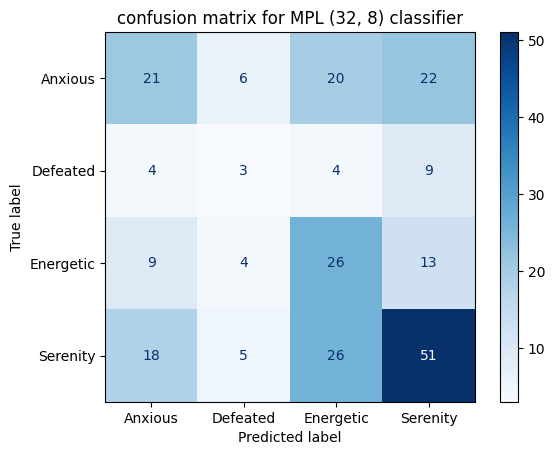

In [112]:
# SHALLOW NEURAL NETWORK (MLPClassifier)


mlp_0 = MLPClassifier(
    hidden_layer_sizes=(),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_0 = cv_classification_report(
    mlp_0, X, y['4_clusters'], CV, label='MPL (0)'
)

confusion_matrix(mlp_0, *training_set, "MPL (0)")

mlp_16 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_16 = cv_classification_report(
    mlp_16, X, y['4_clusters'], CV, label='MPL (16)'
)

confusion_matrix(mlp_16, *training_set, "MPL (16)")

mlp_32_8 = MLPClassifier(
    hidden_layer_sizes=(32, 8),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_32_8 = cv_classification_report(
    mlp_32_8, X, y['4_clusters'], CV, label='MLP (32, 8)'
)
confusion_matrix(mlp_32_8, *training_set, "MPL (32, 8)")


print("Comparison with simpler models:")
print(f"  LR Baseline accuracy : {results_lr_baseline['acc_mean']:.4f}")
print(f"  Decision Tree accuracy: {results_dt['acc_mean']:.4f}")
print(f"  Random Forest accuracy: {results_rf['acc_mean']:.4f}")
print(f"  MLP (16,) accuracy   : {results_mlp_16['acc_mean']:.4f}")
print(f"  MLP (32,8) accuracy  : {results_mlp_32_8['acc_mean']:.4f}")
print("  Neural networks can model non-linear interactions but offer less")
print("  interpretability than logistic regression or decision trees.\n")

In [113]:
all_results = [
    results_lr_baseline,
    results_dt,
    results_rf,
    results_mlp_0,
    results_mlp_16,
    results_mlp_32_8,
]

comparison_data = []
for r in all_results:
    comparison_data.append({
        'Model'                  : r['label'],
        'CV Accuracy (mean+/-std)' : f"{r['acc_mean']:.4f} +/- {r['acc_std']:.4f}",
        'CV F1-macro (mean+/-std)' : f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}",
        '_acc'                   : r['acc_mean'],
        '_f1'                    : r['f1_mean'],
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('_acc', ascending=False)

display_cols = ['Model', 'CV Accuracy (mean+/-std)', 'CV F1-macro (mean+/-std)']
comparison_display = comparison_df[display_cols].reset_index(drop=True)

try:
    from IPython.display import display
    styled = (
        comparison_display.style
        .set_caption("Classifier Comparison — 5-Fold Stratified CV")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('background-color', '#4C72B0'), ('color', 'white')]},
        ])
    )
    display(styled)
except Exception:
    print(comparison_display.to_string(index=False))

best_row = comparison_df.loc[comparison_df['_acc'].idxmax()]
print(f"\nBest model by CV Accuracy: {best_row['Model']}")

                       Model CV Accuracy (mean+/-std) CV F1-macro (mean+/-std)
               Random Forest        0.5092 +/- 0.0162        0.3723 +/- 0.0094
                     MPL (0)        0.5009 +/- 0.0231        0.3555 +/- 0.0221
Logistic Regression Baseline        0.4959 +/- 0.0264        0.3491 +/- 0.0261
                    MPL (16)        0.4867 +/- 0.0220        0.3795 +/- 0.0351
                 MLP (32, 8)        0.4226 +/- 0.0267        0.3426 +/- 0.0182
               Decision Tree        0.3885 +/- 0.0290        0.3162 +/- 0.0221

Best model by CV Accuracy: Random Forest


## Regression

In [114]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score
TARGETS = ["valence_tags", "arousal_tags", "dominance_tags"]

results_store = {}

def cv_regression_report(model, X, y_reg, cv, label):
    '''
    Run 5-fold CV for each regression target and report per-target and
    overall-average MSE and R2.

    Parameters
    ----------
    model   : sklearn estimator (single-output; called once per target)
    X       : feature matrix (numpy array or DataFrame)
    y_reg   : DataFrame with columns valence_tags, arousal_tags, dominance_tags
    cv      : cross-validation splitter (e.g. the shared KFold instance)
    label   : string identifier used in result storage and printing

    Returns
    -------
    record  : dict with "label", per-target MSE/R2, and "avg_mse"/"avg_r2"
    '''
    per_target_mse = {}
    per_target_r2  = {}

    print(f"\n{'='*60}")
    print(f"  Cross-Validation Report — {label}")
    print(f"{'='*60}")

    for target in TARGETS:
        y_col = y_reg[target].values  # 1-D array for this target

        neg_mse_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
        r2_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="r2"
        )

        mean_mse = -neg_mse_scores.mean()
        mean_r2  =  r2_scores.mean()

        per_target_mse[target] = mean_mse
        per_target_r2[target]  = mean_r2

        print(f"  {target:<22}  CV MSE = {mean_mse:.4f}   CV R2 = {mean_r2:.4f}")

    avg_mse = np.mean(list(per_target_mse.values()))
    avg_r2  = np.mean(list(per_target_r2.values()))
    print(f"  {'[AVERAGE]':<22}  CV MSE = {avg_mse:.4f}   CV R2 = {avg_r2:.4f}")
    print(f"{'='*60}")

    record = {"label": label, "avg_mse": avg_mse, "avg_r2": avg_r2}
    for t in TARGETS:
        record[f"mse_{t}"] = per_target_mse[t]
        record[f"r2_{t}"]  = per_target_r2[t]

    results_store[label] = record
    return record


  Cross-Validation Report — Linear Regression
  valence_tags            CV MSE = 2.2291   CV R2 = 0.0684
  arousal_tags            CV MSE = 1.0187   CV R2 = 0.1358
  dominance_tags          CV MSE = 1.1790   CV R2 = 0.0503
  [AVERAGE]               CV MSE = 1.4756   CV R2 = 0.0849


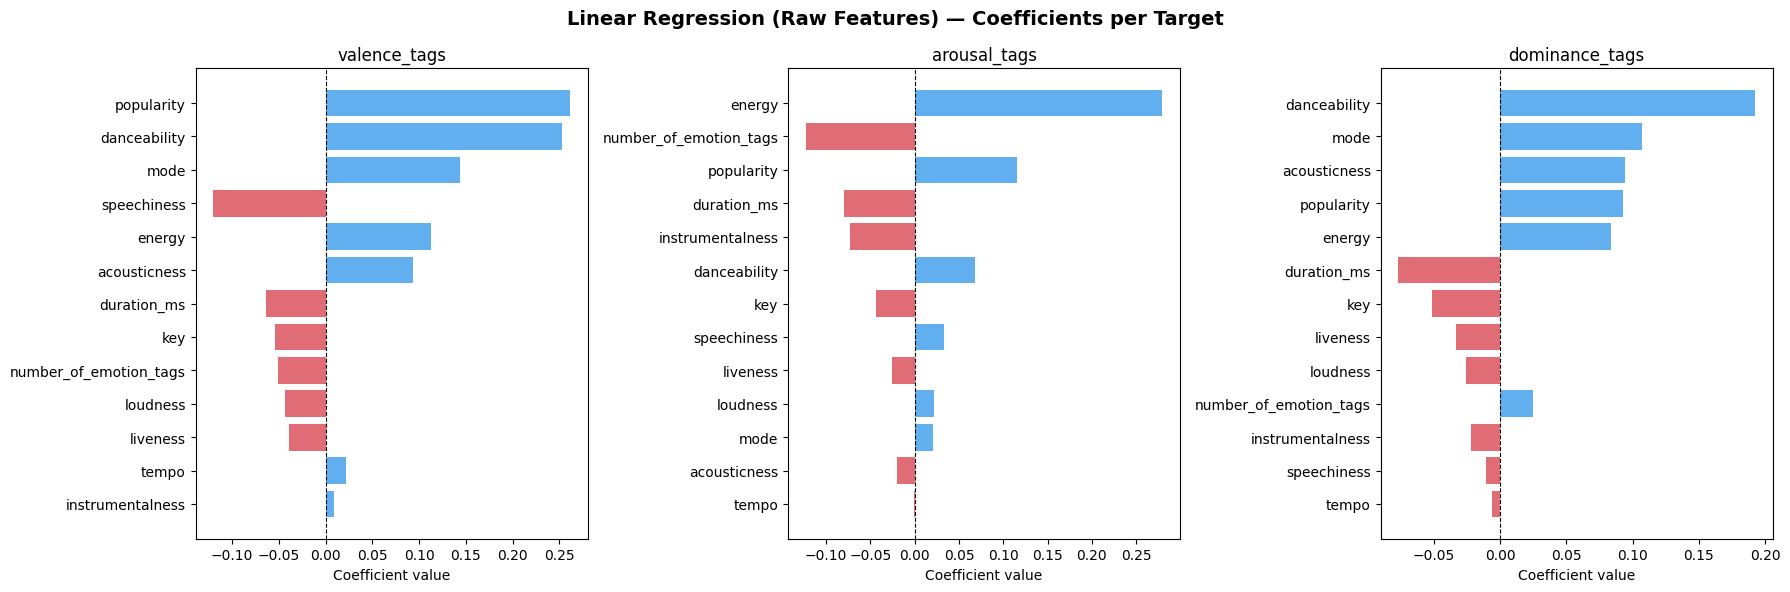


Top-3 most important features by |coefficient| — Raw Linear Regression
------------------------------------------------------------

  valence_tags:
    1. popularity                   coef = +0.2610  (positive)
    2. danceability                 coef = +0.2531  (positive)
    3. mode                         coef = +0.1438  (positive)

  arousal_tags:
    1. energy                       coef = +0.2793  (positive)
    2. number_of_emotion_tags       coef = -0.1227  (negative)
    3. popularity                   coef = +0.1160  (positive)

  dominance_tags:
    1. danceability                 coef = +0.1923  (positive)
    2. mode                         coef = +0.1074  (positive)
    3. acousticness                 coef = +0.0942  (positive)


In [115]:
lr_base = LinearRegression()

# 5-fold CV evaluation
lr_base_record = cv_regression_report(
    lr_base, X, y, CV,
    label="Linear Regression"
)

# ---- Fit on full data to extract coefficients for interpretability ----------
lr_base_fitted_coefs = {}
for target in TARGETS:
    lr_base.fit(X, y[target].values)
    lr_base_fitted_coefs[target] = lr_base.coef_.copy()

# ---- Plot: horizontal bar charts, one subplot per target -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Linear Regression (Raw Features) — Coefficients per Target",
    fontsize=14, fontweight="bold"
)

for ax, target in zip(axes, TARGETS):
    coefs  = lr_base_fitted_coefs[target]
    order           = np.argsort(np.abs(coefs))
    sorted_features = np.array(FEATURE_COLS)[order]
    sorted_coefs    = coefs[order]
    colors = ["#e06c75" if c < 0 else "#61afef" for c in sorted_coefs]
    ax.barh(sorted_features, sorted_coefs, color=colors)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(target, fontsize=12)
    ax.set_xlabel("Coefficient value")

plt.tight_layout()
plt.savefig("./figures/r2_lr_base_coefficients.svg", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop-3 most important features by |coefficient| — Raw Linear Regression")
print("-" * 60)
for target in TARGETS:
    coefs   = lr_base_fitted_coefs[target]
    top_idx = np.argsort(np.abs(coefs))[::-1][:3]
    print(f"\n  {target}:")
    for rank, idx in enumerate(top_idx, 1):
        direction = "positive" if coefs[idx] > 0 else "negative"
        print(
            f"    {rank}. {FEATURE_COLS[idx]:<28} "
            f"coef = {coefs[idx]:+.4f}  ({direction})"
        )


Since features are standardized, the coefficient directly represent relative importance.

### Random forest regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(100,)
# 5-fold CV evaluation
rfr_record = cv_regression_report(
    rfr, X, y, CV,
    label="Random Forest Regressor"
)

# ---- Fit on full data to extract coefficients for interpretability ----------
rfr_feature_importances = {}
for target in TARGETS:
    rfr.fit(X, y[target].values)
    rfr_feature_importances[target] = lr_base.coef_.copy()

    fi_rf = pd.Series(rfr_feature_importances[target], index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    fi_rf.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title('Random Forest — Feature Importances', fontsize=13)
    ax.set_ylabel('Mean Decrease in Impurity', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('c5_rf_feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()



  Cross-Validation Report — Random Forest Regressor
  valence_tags            CV MSE = 2.1867   CV R2 = 0.0952
  arousal_tags            CV MSE = 1.0071   CV R2 = 0.1629
  dominance_tags          CV MSE = 1.1821   CV R2 = 0.0449
  [AVERAGE]               CV MSE = 1.4586   CV R2 = 0.1010


### Shallow neural net regressor
  ()      — no hidden layer, architecturally equivalent to linear regression, used here as a baseline.
  (16,)   — one hidden layer of 16 sigmoid units; minimal capacity, quick to train.
  (32, 8) — two hidden layers; first layer detects feature combinations,
             second layer compresses them toward the output.

  Early stopping is used to prevent overfitting on this
  modest dataset (~1,200 samples).

  Interpretability trade-off: unlike linear coefficients, individual weights
  in the hidden layers have no direct semantic meaning.

In [ ]:

mlp_archs = {
    "MLP ()": MLPRegressor(
        hidden_layer_sizes=(),
        activation="logistic",
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    
    "MLP (16,)": MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="logistic",
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    "MLP (32, 8)": MLPRegressor(
        hidden_layer_sizes=(32, 8),
        max_iter=2000,
        activation="logistic",
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
}



  Cross-Validation Report — MLP ()
  valence_tags            CV MSE = 2.3161   CV R2 = 0.0316
  arousal_tags            CV MSE = 1.0310   CV R2 = 0.1251
  dominance_tags          CV MSE = 1.2140   CV R2 = 0.0217
  [AVERAGE]               CV MSE = 1.5203   CV R2 = 0.0595

  Cross-Validation Report — MLP (16,)
  valence_tags            CV MSE = 2.2326   CV R2 = 0.0672
  arousal_tags            CV MSE = 1.0199   CV R2 = 0.1350
  dominance_tags          CV MSE = 1.1877   CV R2 = 0.0439
  [AVERAGE]               CV MSE = 1.4801   CV R2 = 0.0821

  Cross-Validation Report — MLP (32, 8)
  valence_tags            CV MSE = 2.2832   CV R2 = 0.0456
  arousal_tags            CV MSE = 1.0521   CV R2 = 0.1068
  dominance_tags          CV MSE = 1.2115   CV R2 = 0.0230
  [AVERAGE]               CV MSE = 1.5156   CV R2 = 0.0585


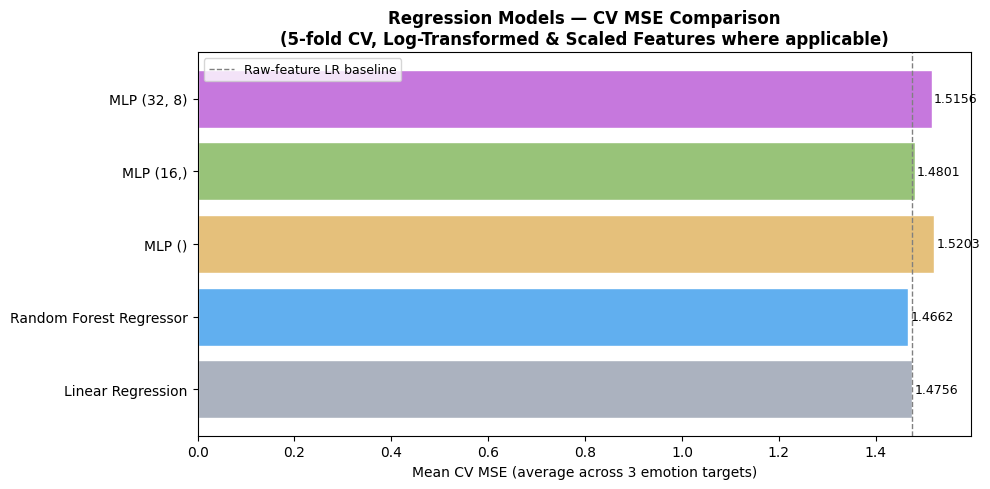

In [ ]:

for arch_label, mlp_model in mlp_archs.items():
    cv_regression_report(
        mlp_model, X, y, CV,
        label=arch_label
    )

# ---- Bar chart: average CV MSE for all regression models so far ------------
comparison_labels = [
    "Linear Regression",
    "Random Forest Regressor",
    "MLP ()",
    "MLP (16,)",
    "MLP (32, 8)",
]
avg_mses = [results_store[lbl]["avg_mse"] for lbl in comparison_labels]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#abb2bf", "#61afef", "#e5c07b", "#98c379", "#c678dd"]
bars   = ax.barh(comparison_labels, avg_mses, color=colors, edgecolor="white")
ax.set_xlabel("Mean CV MSE (average across 3 emotion targets)")
ax.set_title(
    "Regression Models — CV MSE Comparison\n(5-fold CV, Log-Transformed & Scaled Features where applicable)",
    fontsize=12, fontweight="bold"
)
ax.axvline(
    results_store["Linear Regression"]["avg_mse"],
    color="grey", linestyle="--", linewidth=1,
    label="Raw-feature LR baseline"
)
ax.legend(fontsize=9)

for bar, val in zip(bars, avg_mses):
    ax.text(
        val + 0.005, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("r5_mlp_regression_comparison.png", dpi=120, bbox_inches="tight")
plt.show()